<a href="https://colab.research.google.com/github/narayanpawar07092007-cell/Customer-clustering/blob/main/CNN_classify_hand_gestures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
from google.colab import files
uploaded = files.upload()   # choose the zip file

Saving archive (1).zip to archive (1).zip


In [19]:
import zipfile
import os

# Get the name of the uploaded file from the 'uploaded' dictionary
zip_path = list(uploaded.keys())[0]

# Write the uploaded file content to the filesystem
with open(zip_path, 'wb') as f:
    f.write(uploaded[zip_path])

extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted to:", extract_path)

Files extracted to: dataset


In [20]:
# Verify extraction
for root, dirs, files in os.walk(extract_path):
    print(root, "->", len(files), "files")

dataset -> 0 files
dataset/TwoFinger -> 2005 files
dataset/Fist -> 2003 files
dataset/OpenHand -> 2010 files


In [25]:
import cv2
import numpy as np

data, labels = [], []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".jpg"): # Changed from .png to .jpg
            img = cv2.imread(os.path.join(root, file), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (64,64))
            data.append(img/255.0)
            labels.append(root.split("/")[-1])  # folder name = gesture label

X = np.array(data).reshape(-1,64,64,1)
y = np.array(labels)

In [26]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42
)

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,624,963 (6.20 MB)

 Trainable params: 1,624,963 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 26s 162ms/step - accuracy: 0.6857 - loss: 0.6952 - val_accuracy: 0.9850 - val_loss: 0.0672
Epoch 2/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 41s 160ms/step - accuracy: 0.9706 - loss: 0.0957 - val_accuracy: 0.9958 - val_loss: 0.0153
Epoch 3/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 24s 160ms/step - accuracy: 0.9861 - loss: 0.0352 - val_accuracy: 0.9983 - val_loss: 0.0059
Epoch 4/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 41s 159ms/step - accuracy: 0.9911 - loss: 0.0256 - val_accuracy: 0.9983 - val_loss: 0.0087
Epoch 5/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 24s 159ms/step - accuracy: 0.9971 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 7.5329e-04
Epoch 6/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 41s 159ms/step - accuracy: 0.9950 - loss: 0.0130 - val_accuracy: 1.0000 - val_loss: 9.9268e-04
Epoch 7/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 24s 159ms/step - accuracy: 0.9891 - loss: 0.0293 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 8/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 24s 159ms/step - accuracy: 0.9984 -

In [29]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 1.0000 - loss: 5.3815e-04
Test Accuracy: 1.00


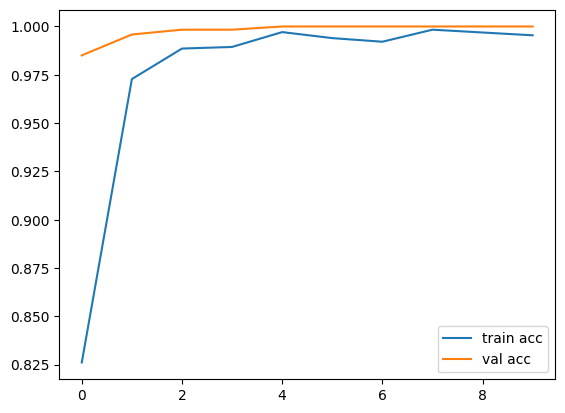

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


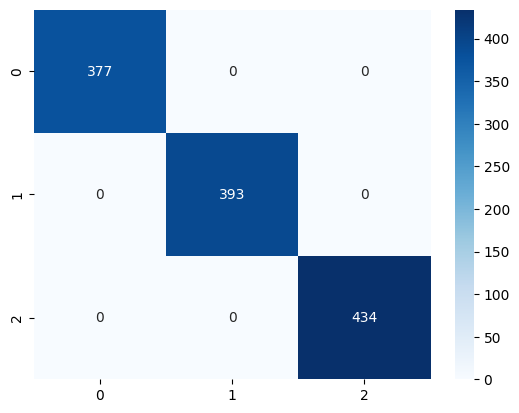

              precision    recall  f1-score   support

        Fist       1.00      1.00      1.00       377
    OpenHand       1.00      1.00      1.00       393
   TwoFinger       1.00      1.00      1.00       434

    accuracy                           1.00      1204
   macro avg       1.00      1.00      1.00      1204
weighted avg       1.00      1.00      1.00      1204



In [31]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=le.classes_))